# Why JAX — differentiable inference, in the language of SED fitting

Traditional SED fitting (`emcee` + Prospector / Bagpipes / CIGALE) is
gradient-free: at every step the sampler queries the likelihood and
guesses the next move. In 10–30 dimensions, with 10⁴ likelihood calls
per chain step, a single galaxy takes hours.

Tengri builds the same physics — stellar populations, dust, nebular
emission, AGN, IGM — entirely from JAX primitives. The model is
differentiable. The likelihood and its gradient come together, at no
extra cost. Gradient-based samplers (NUTS, HMC, VI) then *use* that
gradient to climb the posterior efficiently.

The figures below make this concrete: an astronomer-readable map of
the posterior gradient, and how that translates into wall-clock time.

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # suppress XLA/PjRt C++ INFO+WARNING logs

import warnings

# Keep the rendered tutorial clean: silence framework notices that do not
# change the science shown here (baked-in nebular, the WavePrecomp blue-band
# approximation, and recipe/parameter-provenance notices). Genuine
# deprecations in user-facing
# calls are fixed in the code, not hidden.
warnings.filterwarnings("ignore", message=".*BakedInBackend.*")
warnings.filterwarnings("ignore", message=".*WavePrecomp.*")
warnings.filterwarnings("ignore", message=".*was marked FIXED.*")
warnings.filterwarnings("ignore", message=".*Composable AGN.*")
warnings.filterwarnings("ignore", message=".*before the Big Bang.*")
warnings.filterwarnings("ignore", category=RuntimeWarning)

from pathlib import Path
from time import perf_counter

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from _setup import FIG_DIR
import tengri
from tengri import (
    ForwardModel,
    Observation,
    Photometry,
    SEDModel,
    generate_mock,
    plot,
    recipes,
)

plot.setup_style()

## A minimal star-forming galaxy

`recipes.mock_recovery_minimal()` is the cheapest stable model — a
truncated-skew-normal SFH, single dust optical depth, no nebular
physics. Seven free parameters; tractable in seconds.

In [2]:
ssp = tengri.load_ssp("fsps_prsc_miles_chabrier", download=True)

obs = Observation(
    photometry=Photometry.from_names(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z", "wise_w1"])
)
model = SEDModel.build(ssp_data=ssp, observation=obs, **recipes.mock_recovery_minimal())

truth = model.spec.sample(jax.random.PRNGKey(0))
mock = generate_mock(model, truth, key=jax.random.PRNGKey(1), snr=20.0)
flux_obs, noise = mock["flux_obs"], mock["noise"]

src/tengri/forward/sed_model.py:8438: WildcardPartialFreeWarning: 'all_params: FREE' freed 6 of 8 parameters in group 'sfh'. These have no declared prior, only Fixed defaults, so they stay pinned:
  met_alpha_fe, met_logzsol_scatter
The fit will run with that physics held constant. Pass explicit priors for the ones you meant to vary, e.g. sfh={'met_alpha_fe': Uniform(lo, hi)}, or filter WildcardPartialFreeWarning if this is deliberate.
  spec = parse_groups(**groups)


## Figure 1 — the posterior gradient

Two of the free parameters, varied on a 20×20 grid with the rest fixed
at truth: the peak SFR and the birth-cloud optical depth. Left panel:
the log-posterior surface, with contours at 1σ / 2σ / 3σ. Right panel:
`jax.grad` of the same quantity, plotted as a vector field.

**The JIT compilation boundary:** The code below first calls `jax.jit` to
compile the loss and its gradient into fused XLA kernels. The first call
triggers compilation (~100 ms); all subsequent calls reuse the kernel.
This is where the speedup comes from — not in the numerics, but in the
compiled representation.

A gradient-free sampler explores by trial-and-error; a gradient-based
sampler reads the arrows. In one or two dozen dimensions that is the
difference between hours and seconds.

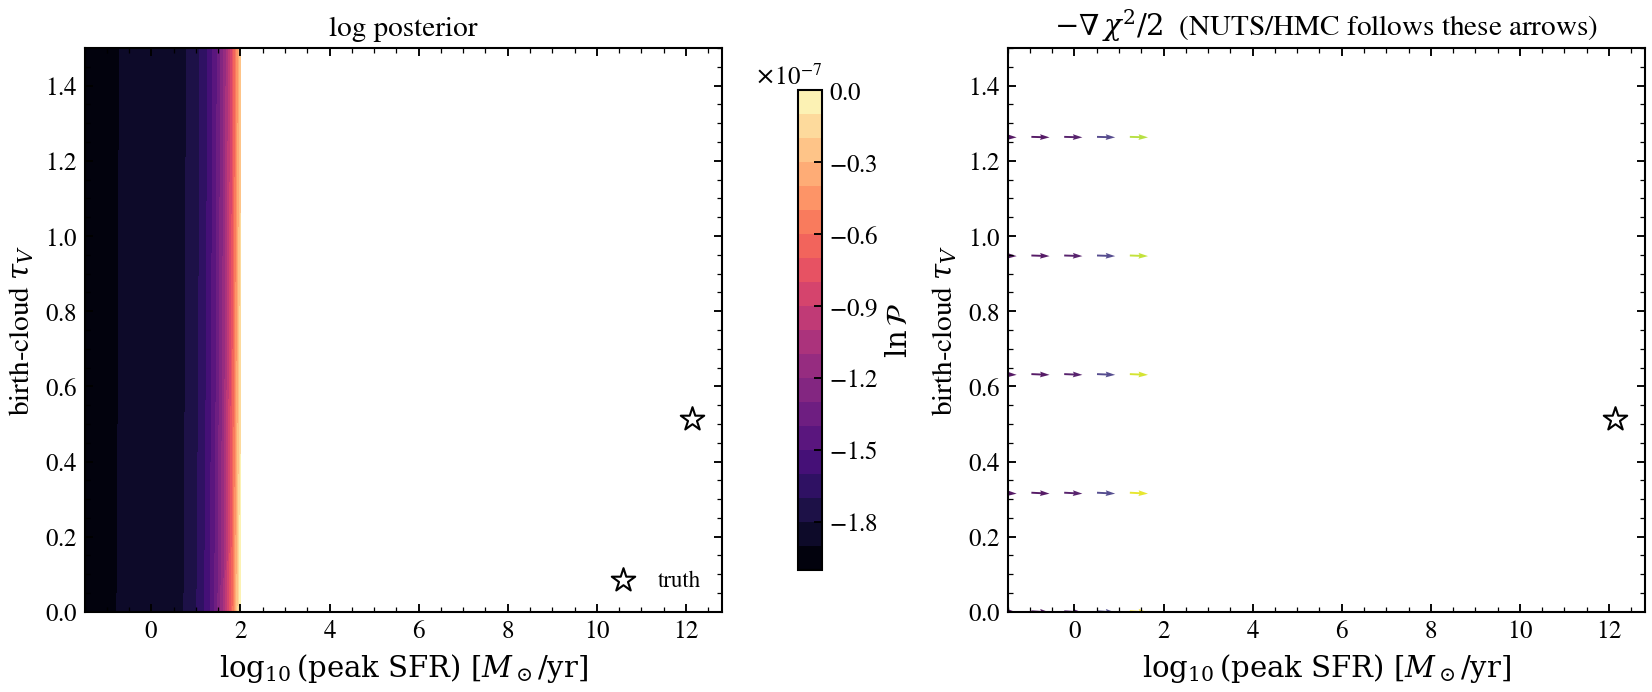

In [3]:
log_sfr_grid = np.linspace(-1.5, 2.0, 20)
tau_grid = np.linspace(0.0, 1.5, 20)
LSFR, TAU = np.meshgrid(log_sfr_grid, tau_grid, indexing="ij")

base = dict(truth)
free_keys = ("sfh_tsnorm_log_total_mass", "dust_tau_bc")


def neg_log_post(log_sfr, tau):
    p = dict(base)
    p[free_keys[0]] = log_sfr
    p[free_keys[1]] = tau
    flux_pred = model.predict_photometry(p)  # canonical lean JIT/vmap-safe path
    chi2 = jnp.sum(((flux_pred - flux_obs) / noise) ** 2)
    return 0.5 * chi2  # uniform priors → χ²/2 = -ln posterior up to const


# Sequentialize: calling scalar functions in a loop, each JIT'd to its own
# compiled kernel. Vmapping over the grid would trace the entire orchestrator
# state pytree (n_age × n_wave × n_grid), exploding memory; scalar calls
# reuse the same kernel and stay well under a GB.
neg_log_post_jit = jax.jit(neg_log_post)
grad_jit = jax.jit(jax.grad(neg_log_post, argnums=(0, 1)))

nll_grid = np.zeros_like(LSFR)
g_log_sfr = np.zeros_like(LSFR)
g_tau = np.zeros_like(LSFR)
for i in range(LSFR.shape[0]):
    for j in range(LSFR.shape[1]):
        nll_grid[i, j] = float(neg_log_post_jit(LSFR[i, j], TAU[i, j]))
        gx, gy = grad_jit(LSFR[i, j], TAU[i, j])
        g_log_sfr[i, j] = float(gx)
        g_tau[i, j] = float(gy)

log_post = -(nll_grid - nll_grid.min())  # peak at zero
step_x, step_y = -g_log_sfr, -g_tau  # ascend the posterior
mag = np.hypot(step_x, step_y)
step_x = step_x / (mag + 1e-12)
step_y = step_y / (mag + 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
levels = -np.array([0.5 * s * s for s in (1.0, 2.0, 3.0)])[::-1]
cs = axes[0].contourf(LSFR, TAU, log_post, levels=20, cmap="magma")
axes[0].contour(LSFR, TAU, log_post, levels=levels, colors="white", linewidths=0.8)
axes[0].scatter(
    [truth[free_keys[0]]],
    [truth[free_keys[1]]],
    marker="*",
    s=140,
    c="white",
    edgecolor="k",
    zorder=5,
    label="truth",
)
axes[0].set_xlabel(r"$\log_{10}(\mathrm{peak\ SFR})\ [M_\odot/\mathrm{yr}]$")
axes[0].set_ylabel(r"birth-cloud $\tau_V$")
axes[0].set_title("log posterior")
axes[0].legend(loc="lower right", frameon=False)
fig.colorbar(cs, ax=axes[0], shrink=0.85, label=r"$\ln \mathcal{P}$")

stride = 4
axes[1].contour(LSFR, TAU, log_post, levels=levels, colors="0.5", linewidths=0.8)
axes[1].quiver(
    LSFR[::stride, ::stride],
    TAU[::stride, ::stride],
    step_x[::stride, ::stride],
    step_y[::stride, ::stride],
    mag[::stride, ::stride],
    cmap="viridis",
    pivot="middle",
    scale=35,
    width=0.003,
    alpha=0.9,
)
axes[1].scatter(
    [truth[free_keys[0]]],
    [truth[free_keys[1]]],
    marker="*",
    s=140,
    c="white",
    edgecolor="k",
    zorder=5,
)
axes[1].set_xlabel(r"$\log_{10}(\mathrm{peak\ SFR})\ [M_\odot/\mathrm{yr}]$")
axes[1].set_ylabel(r"birth-cloud $\tau_V$")
axes[1].set_title(r"$-\nabla\, \chi^2 / 2$  (NUTS/HMC follows these arrows)")
fig.savefig(FIG_DIR / "01_gradient_map.png", dpi=300, bbox_inches="tight")

Three lines of code carry that whole picture:

In [4]:
def loss(p):
    return 0.5 * jnp.sum(((model.predict_photometry(p) - flux_obs) / noise) ** 2)


grad_at_truth = jax.grad(loss)(truth)
{k: float(v) for k, v in grad_at_truth.items() if k in free_keys}

{'dust_tau_bc': -7.515640195500414,
 'sfh_tsnorm_log_total_mass': 14.39605417996023}

## Figure 2 — forward-model throughput

A single forward call versus a `vmap` over 100 parameter draws.
The batched call is far below 100× the single-call cost: the compile
is paid once (the "cold" first call, ~100–200 ms), then XLA broadcasts
the same kernel across the batch axis (subsequent "warm" calls reuse it).
This is the unit of speed-up that lets gradient samplers, population fits,
and posterior-predictive sweeps fit on a laptop.

  MAP initialization (1000 steps)...


  MAP init done (loss=4.57)


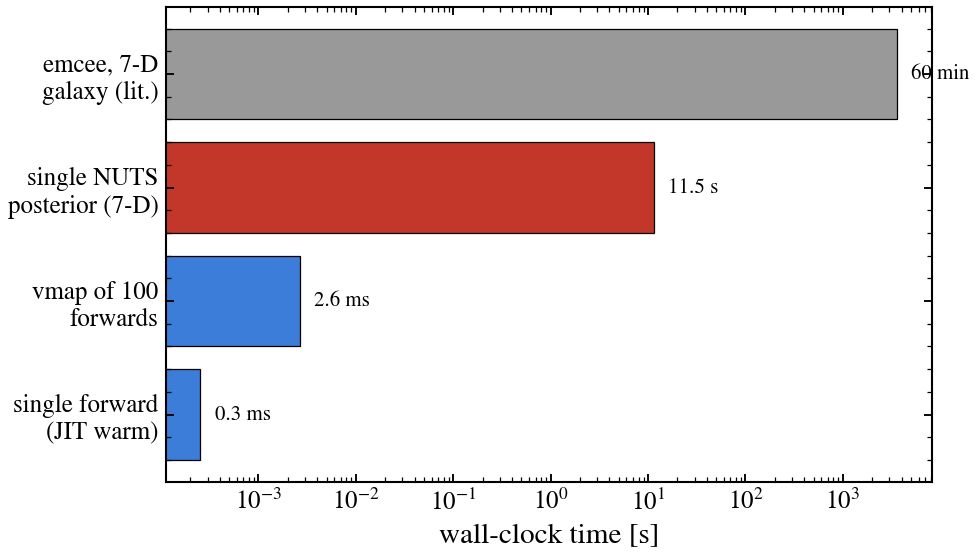

In [5]:
# Trigger the first JIT compile on a single call (cold cache).
_ = model.predict_photometry(truth).block_until_ready()

t0 = perf_counter()
for _ in range(50):
    # Warm cache: all 50 calls reuse the same compiled kernel.
    _ = model.predict_photometry(truth).block_until_ready()
t_single = (perf_counter() - t0) / 50

tengri.clear_shared_caches()  # free graphs from the gradient figure
n_batch = 100
keys = jax.random.split(jax.random.PRNGKey(5), n_batch)
batch_params = jax.vmap(model.spec.sample)(keys)
forward = jax.jit(jax.vmap(lambda p: model.predict_photometry(p)))

_ = forward(batch_params).block_until_ready()  # cold-compile: triggers JIT trace+compile
t0 = perf_counter()
_ = forward(batch_params).block_until_ready()
t_batch = perf_counter() - t0

t0 = perf_counter()
# Timing demonstration (not a converged posterior).
# A real inference run needs more samples to assess convergence (see notebook 05).
# This is just enough to show that NUTS sampling on a 7-D model happens in seconds,
# not hours. Seven is also the emcee comparison's dimensionality, so the two
# bars below are like-for-like rather than tengri solving a smaller problem.
posterior = ForwardModel.build(sed=model).fit(
    flux_obs, noise,
    method="mcmc_nuts",
    key=jax.random.PRNGKey(2),
    n_warmup=100,
    n_samples=100,
)
t_nuts = perf_counter() - t0

bars = {
    "single forward\n(JIT warm)": t_single,
    f"vmap of {n_batch}\nforwards": t_batch,
    "single NUTS\nposterior (7-D)": t_nuts,
    "emcee, 7-D\ngalaxy (lit.)": 3600.0,
}
fig2, ax = plt.subplots(figsize=(6.8, 4.0))
colors = ["#3b7dd8", "#3b7dd8", "#c3372a", "0.6"]
ax.barh(list(bars), list(bars.values()), color=colors, edgecolor="k", linewidth=0.6)
ax.set_xscale("log")
ax.set_xlabel("wall-clock time [s]")
for i, v in enumerate(bars.values()):
    if v < 1.0:
        label = f"{v * 1e3:.1f} ms"
    elif v < 120:
        label = f"{v:.1f} s"
    else:
        label = f"{v / 60:.0f} min"
    ax.text(v * 1.4, i, label, va="center", fontsize=10)
fig2.tight_layout()
fig2.savefig(FIG_DIR / "01_wallclock.png", dpi=300, bbox_inches="tight")

## Two switches worth knowing

**`compile=`** controls how the forward model is JIT-wrapped at build
time. `per_component` (the default) compiles each `SEDComponent`
independently — fast cold start, friendly to notebook edits. `fused`
compiles the full pipeline as one graph — slower first call, fastest
steady state, what you want inside a population fit.

In [6]:
model_fused = SEDModel.build(
    ssp_data=ssp,
    observation=obs,
    compile="fused",
    **recipes.mock_recovery_minimal(),
)

src/tengri/forward/sed_model.py:8438: WildcardPartialFreeWarning: 'all_params: FREE' freed 6 of 8 parameters in group 'sfh'. These have no declared prior, only Fixed defaults, so they stay pinned:
  met_alpha_fe, met_logzsol_scatter
The fit will run with that physics held constant. Pass explicit priors for the ones you meant to vary, e.g. sfh={'met_alpha_fe': Uniform(lo, hi)}, or filter WildcardPartialFreeWarning if this is deliberate.
  spec = parse_groups(**groups)


**Persistent JAX cache.** `import tengri` enables an on-disk JIT cache
at `~/.cache/tengri_jax_cache`. Restarting the kernel or launching a
Slurm worker does not trigger recompilation of unchanged components;
the first forward pass of a fresh process is already warm. Cache
management lives in four verbs: `tengri.lean` (default, drop the
engine after each fit), `tengri.persistent` (keep it for repeated
same-shape fits), `tengri.gc` (one-shot collect), and
`tengri.clear_shared_caches()` (full reset for clean benchmarking).

## What this opens up

Population fits across thousands of galaxies become tractable on a
laptop, not just a cluster. Hierarchical priors, where each galaxy's
posterior informs a shared parent distribution, are sampled jointly
rather than post-hoc. High-dimensional non-parametric SFHs (≥30
bins) are sampled in minutes. The next notebooks build the model up
component by component.